# Retail Demand Intelligence — Full Story
### M5 Walmart Sales Dataset

---

This notebook tells the complete story of the project from business question through results.
Every modeling decision is explained, every result is interpreted, and every chart connects
back to a concrete business implication.

> **Important framing:** This system models demand using observed sales as a proxy for
> latent demand. True demand is unobservable — we have no inventory records or stockout
> logs to distinguish "product did not sell" from "product was not available to sell."
> All outputs are demand approximations that support inventory decisions. They are not
> exact demand recovery, and this distinction is carried honestly through every result.

**Charts live in:** `outputs/presentation_charts/`

In [1]:
from IPython.display import Image, display
import os

CHART_DIR = '../outputs/presentation_charts'

def show(filename, width=1000):
    path = os.path.join(CHART_DIR, filename)
    display(Image(filename=path, width=width))

---
---

# PART 1 — THE PROBLEM

---

## 1.1 — What does Walmart actually need?

Walmart runs over 10,000 stores. Every store carries thousands of products.
Every one of those products needs to be on the shelf at the right time — not too much, not too little.

**If you order too much:** product expires, takes up shelf space, gets marked down at a loss.

**If you order too little:** the shelf is empty when a customer wants to buy. This is called a **stockout**.
You lose the sale, and possibly the customer permanently.

The decision of how much to order depends on estimating future demand — how many units a specific
product at a specific store is likely to sell in a given period. This is a **demand intelligence**
problem, and it is genuinely hard.

---

### Key definitions

| Term | Definition |
|---|---|
| **Demand modeling** | Estimating how many units of a specific product a specific store is likely to sell in a future time period, using observed sales as a proxy for latent demand |
| **Latent demand** | The true underlying demand — what customers would buy if the product were always available. We cannot observe this directly without stockout and inventory data |
| **Observed sales** | What we actually have: units sold when the product was on the shelf. This is our demand proxy throughout the project |
| **Stockout** | A product is out of stock when a customer wants to buy it — the sale is lost and demand goes unrecorded |
| **Overstock** | Too much inventory ordered — leads to waste, markdowns, or expired product |
| **Decision support** | Our goal is not to perfectly predict demand. It is to approximate demand well enough to make better ordering decisions than a simple heuristic would |
| **Hierarchy** | Demand approximations can be made at different aggregation levels — platform total, store, department, individual product. Different levels serve different decision needs |

---

### The business question

> *Given a product's observed sales history, price history, upcoming holidays, and local
> events — how well can we approximate demand at a specific store over the next month?
> And where does the approximation break down in ways that flag genuine demand anomalies?*

The scale of the challenge: we are not approximating demand for one product.
We are doing it for **30,490 product-store combinations simultaneously**, each with
its own demand pattern, price history, and local context.

### What this system is and is not

| This system IS | This system IS NOT |
|---|---|
| A demand approximation pipeline using observed sales as a proxy | An inventory optimization system |
| A decision-support tool that narrows the ordering range | A system that tells you exactly how many units to order |
| Honest about uncertainty — wide intervals are communicated, not hidden | A system that claims to recover true latent demand |
| A baseline that motivates the ML layer via signal ceiling analysis | A finished production forecasting system |

---

## 1.2 — The dataset: M5 Walmart

We use the **M5 Forecasting dataset** — a real Walmart sales dataset released for a Kaggle
competition in 2020. This is not simulated data. These are actual Walmart transactions.

### Scale

| Dimension | Value |
|---|---|
| Unique product-store series | 30,490 |
| Unique products | 3,049 |
| Stores | 10 (across CA, TX, WI) |
| Date range | Jan 29 2011 → Apr 24 2016 (5.25 years) |
| Daily observations | 1,913 days |
| Total rows (long format) | 58,327,370 |

### Three source files

| File | What it contains | How we use it |
|---|---|---|
| `sales_train_validation.csv` | Units sold per product-store per day (wide format) | Primary demand proxy — reshaped to long format |
| `calendar.csv` | Dates, day-of-week, events, holidays, SNAP flags | Join to get real dates and observable external demand drivers |
| `sell_prices.csv` | Weekly price per product per store | Join to compute revenue = units × price |

### Important: revenue is derived, not directly observed

We compute revenue as `units_sold × sell_price`. The price join introduces minor gaps
for product-store-week combinations with no price record — these are filled with zero,
slightly understating observed demand for products with incomplete price histories.
More fundamentally: **observed revenue is a proxy for demand, not demand itself**.
A zero in the data could mean no one wanted the product, or it could mean the shelf
was empty. We cannot distinguish these cases without inventory records.

### Wide format vs long format

The sales file arrives in **wide format** — one row per product, one column per day (1,913 columns).
This is unusable for time series analysis. We reshape it to **long format** — one row
per product-store-day — before any analysis is possible. This produces 58 million rows.

---

## 1.3 — Why this dataset is hard: zero-inflation and demand ambiguity

The first thing you discover when you look at the data is that most product-store-days
have **zero observed sales**.

**68.2% of all product-store-days have zero units sold.**

If you pick any specific product at any specific store on any given day, there is a 68% chance
the observed sales count is zero. This is not a data quality issue — it is a fundamental
characteristic of retail demand at the individual series level.

### Two types of zeros — this distinction matters for demand interpretation

| Type | Description | Demand interpretation |
|---|---|---|
| **Intermittent demand zeros** | The product is stocked but did not sell that day | Genuine demand absence — no customer wanted it that day |
| **Structural zeros** | The product was not available at that store — not yet launched, discontinued, or out of stock | Demand is unknown — it may have existed but went unrecorded |

**Mean longest zero streak per series: 430 consecutive days.**
44% of series have a streak longer than 365 days — meaning a specific product at a specific
store recorded zero observed sales every single day for over a year.
These are overwhelmingly structural zeros — product lifecycle gaps, not absent demand.

### Why this matters for the demand intelligence system

Without stockout and inventory records, we cannot formally separate intermittent demand
zeros from structural zeros. This is a **fundamental limitation of using observed sales
as a demand proxy**, and it propagates through every modeling decision:

- Lag features must not span structural zero gaps — pulling signal from a period when
  a product was unavailable conflates supply absence with demand absence
- Anomaly detection must distinguish demand spikes from product relaunch events
- Individual series confidence intervals must be communicated as wide, not suppressed

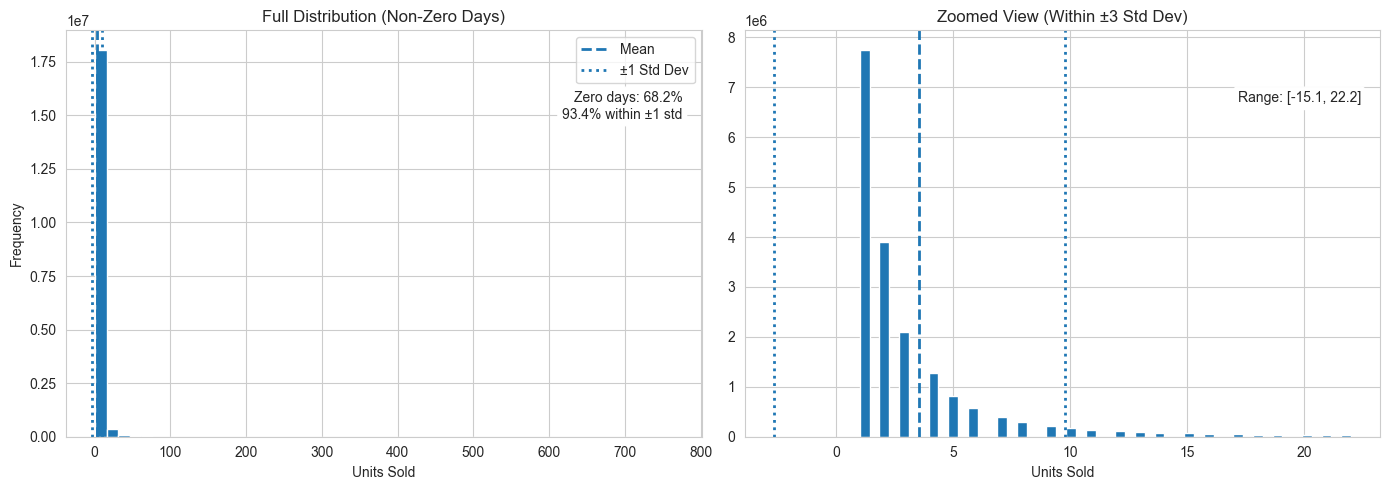

In [2]:
show('02_zero_inflation.png')

**Reading this chart:** The distribution of observed sales on non-zero days is extremely
right-skewed. The median is 2 units, but the tail extends to 763 units in a single day
at one store. Most individual series exhibit low, intermittent observed demand —
the reliable demand signal emerges through aggregation, not at the individual series level.

---
---

# PART 2 — EXPLORATORY DATA ANALYSIS

---

## EDA philosophy: every finding drives a modeling decision

EDA here is not exploratory in the casual sense. Every finding below directly determined
a modeling choice — which features to engineer, which series to model, how to interpret
errors, and where the univariate signal ceiling lies. We flag each decision explicitly.

---

## 2.1 — Finding 1: Where the demand signal is concentrated

Before modeling anything we need to understand which products and stores carry the
most reliable observed demand signal. Not all series are worth modeling equally —
high-volume series have more signal relative to noise, making demand approximations
more stable and more actionable.

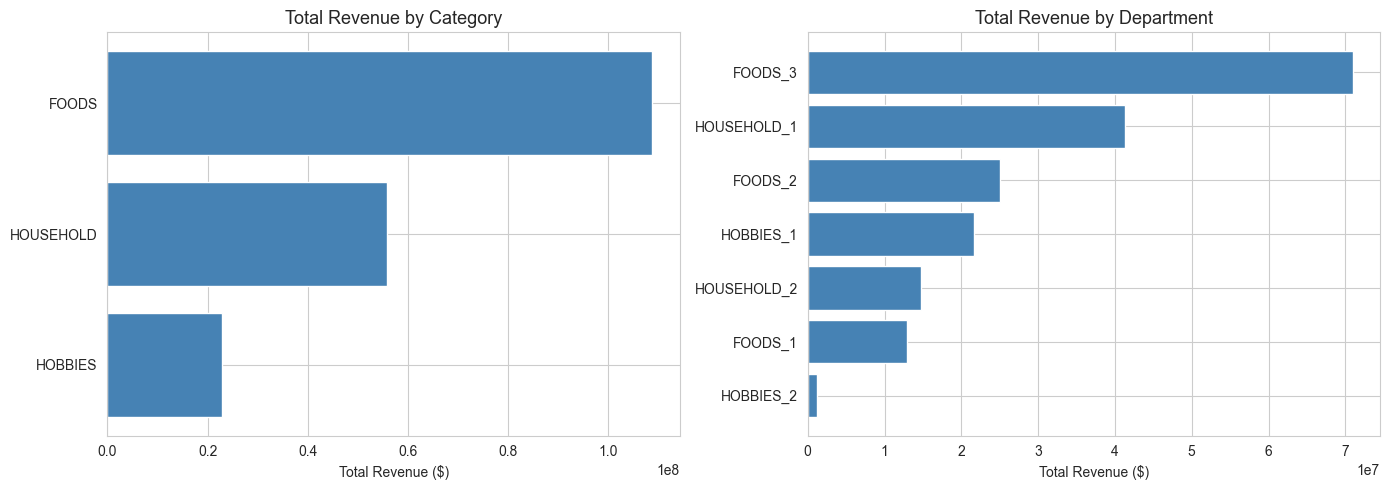

In [3]:
show('03_revenue_by_category.png')

### Key findings

| Finding | Value |
|---|---|
| FOODS share of total observed revenue | 58% ($108.9M) |
| FOODS_3 alone | 37.8% — single largest department |
| CA_3 (highest observed demand store) | 17.1% of platform revenue |
| CA_4 (lowest observed demand store) | 6.5% — same state as CA_3 |
| HOBBIES_2 | 0.63% — highly intermittent, low-density demand signal |

**CA_3 generates nearly 3× the observed revenue of CA_4, despite being in the same state.**
This reflects real differences in store size, local demographics, and product mix —
not noise. State alone is not a sufficient encoding — store-level features are essential.

### Modeling decision
Our representative individual series is drawn from FOODS_3 at CA_3 — the highest observed
demand department at the highest observed demand store. This maximises the signal available
for individual-level demand modeling. HOBBIES_2 demand is too intermittent and sparse
to produce reliable approximations at the individual series level.

---

## 2.2 — Finding 2: Trend and seasonality in aggregate observed demand

The aggregate monthly revenue series — all products, all stores, summed — is the foundation
for our platform-level statistical baselines. Before selecting any model parameters we
decompose its structure formally.

### What is seasonal decomposition?

Any time series can be mathematically separated into three components:

| Component | What it is | Demand interpretation |
|---|---|---|
| **Trend** | The underlying direction of the series over years | Long-run demand growth or contraction |
| **Seasonality** | The repeating calendar pattern — same every 12 months | Predictable seasonal demand variation |
| **Residual** | Everything left after removing trend and seasonality | Demand variation driven by promotions, events, external shocks — and measurement noise from the observed-sales proxy |

We use **additive decomposition**: `observed = trend + seasonal + residual`.
This assumes the seasonal amplitude stays constant regardless of the trend level.
As we will see in the Prophet results, this assumption does not hold at the aggregate level —
multiplicative seasonality fits better as observed demand grows.

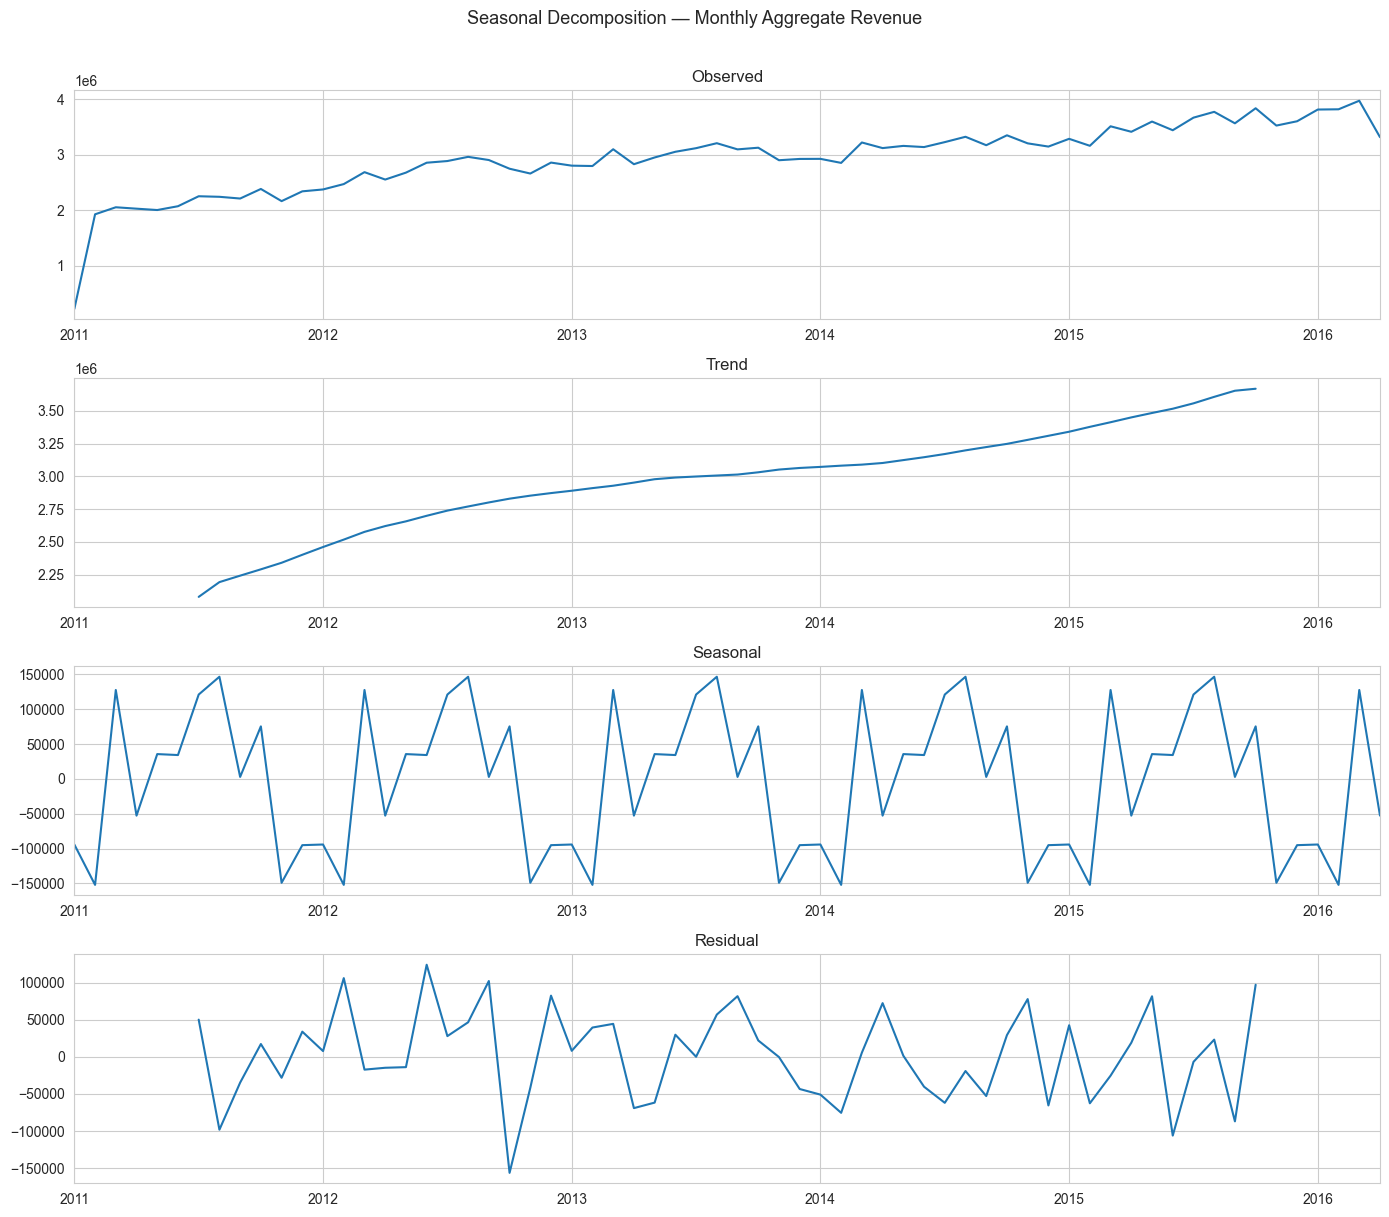

In [4]:
show('04_seasonal_decomposition.png')

### Reading this chart

**Observed (top):** Raw monthly observed demand (proxied by revenue). Both the upward
trend and slight waviness are visible, but they are difficult to disentangle visually —
that is what the decomposition achieves.

**Trend:** Observed demand grew steadily from ~$2M/month in 2011 to ~$4M/month by 2016
— roughly doubling over 5 years. This likely reflects a combination of genuine consumer
demand growth and Walmart's expanding product range. We interpret it as an approximated
demand trend, not a confirmed measure of latent demand growth.

**Seasonal:** The repeating annual pattern in observed demand. August and March show
the strongest positive deviations (+$147K and +$128K), while February and November
are weakest. These patterns likely reflect predictable consumer behavior — back-to-school,
seasonal food preferences — though without controlled studies we treat them as observed
demand patterns rather than confirmed causal effects. Crucially: the seasonal amplitude
is **small relative to the trend**. Trend dominates. Any model that cannot extrapolate
trend accurately will degrade at longer forecast horizons.

**Residual:** Observed demand variation not explained by trend or seasonality — promotions,
weather, local events, and the inherent noise of using observed sales as a demand proxy.
Well-behaved here: random-looking with no obvious remaining structure.

### Modeling decision
The strong, persistent trend directly motivates why Prophet outperforms SARIMA on this
series. SARIMA mean-reverts at long horizons. Prophet extrapolates the trend forward.
The choice between them is empirically confirmed by the held-out test results in Part 4.

---

## 2.3 — Finding 3: SNAP as a predictable external demand driver

The calendar file contains SNAP flags — one of the most operationally valuable signals
in the dataset, because it is both measurable and known in advance.

### What is SNAP?

**SNAP (Supplemental Nutrition Assistance Program)** is the US government food assistance
program. Benefits are distributed to eligible households on specific days each month.
When benefits are distributed, households spend them immediately — producing a predictable
observed demand spike at grocery stores.

**Critically: each state has a different SNAP distribution schedule.** California, Texas,
and Wisconsin each have their own calendar. The demand response also differs by state —
reflecting different household income profiles and store footprints. A single global SNAP
flag would lose this state-specific variation.

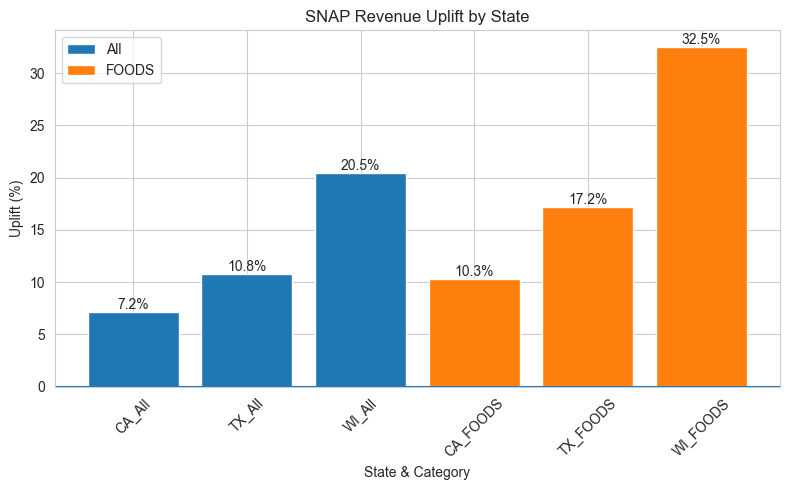

In [5]:
show('05_snap_effect.png')

### SNAP observed demand uplift — all categories vs FOODS only

| State | All categories | FOODS category only |
|---|---|---|
| Wisconsin | +20.5% | +32.5% |
| Texas | +10.8% | +17.2% |
| California | +7.2% | +10.3% |

The observed demand uplift nearly doubles when isolating FOODS — which makes sense,
since SNAP benefits are restricted to food purchases. Wisconsin's effect is the strongest,
consistent with a smaller store footprint and higher proportion of SNAP-dependent households.

These uplifts are among the largest, most consistent external demand signals in the dataset.
Importantly, the SNAP calendar is **known in advance** — this is not a signal we have to
infer from history. It is a predictable, scheduled external demand driver.

### Modeling decision
SNAP flags must be encoded as **state-level features** in XGBoost: `snap_CA`, `snap_TX`,
`snap_WI` as three separate binary inputs. A single `is_snap_day` flag would collapse
the different state-level demand responses into one number and lose the variation that
makes the feature valuable. SARIMA and Prophet are completely blind to these signals —
they read only the revenue time series and have no mechanism to observe the SNAP calendar.

---

## 2.4 — Finding 4: Price elasticity in observed demand

Prices change week over week in this dataset. Understanding how observed demand responds
to price changes — and at what level of granularity that response is detectable — directly
determines the price features we engineer for XGBoost.

### What is price elasticity?

**Price elasticity** measures how sensitive observed demand is to price changes.
**Asymmetric elasticity** means customers respond differently to price drops vs price
increases — stocking up aggressively on discounts but not proportionally reducing
purchases when prices rise.

### We tested at three levels of granularity — the results differ dramatically

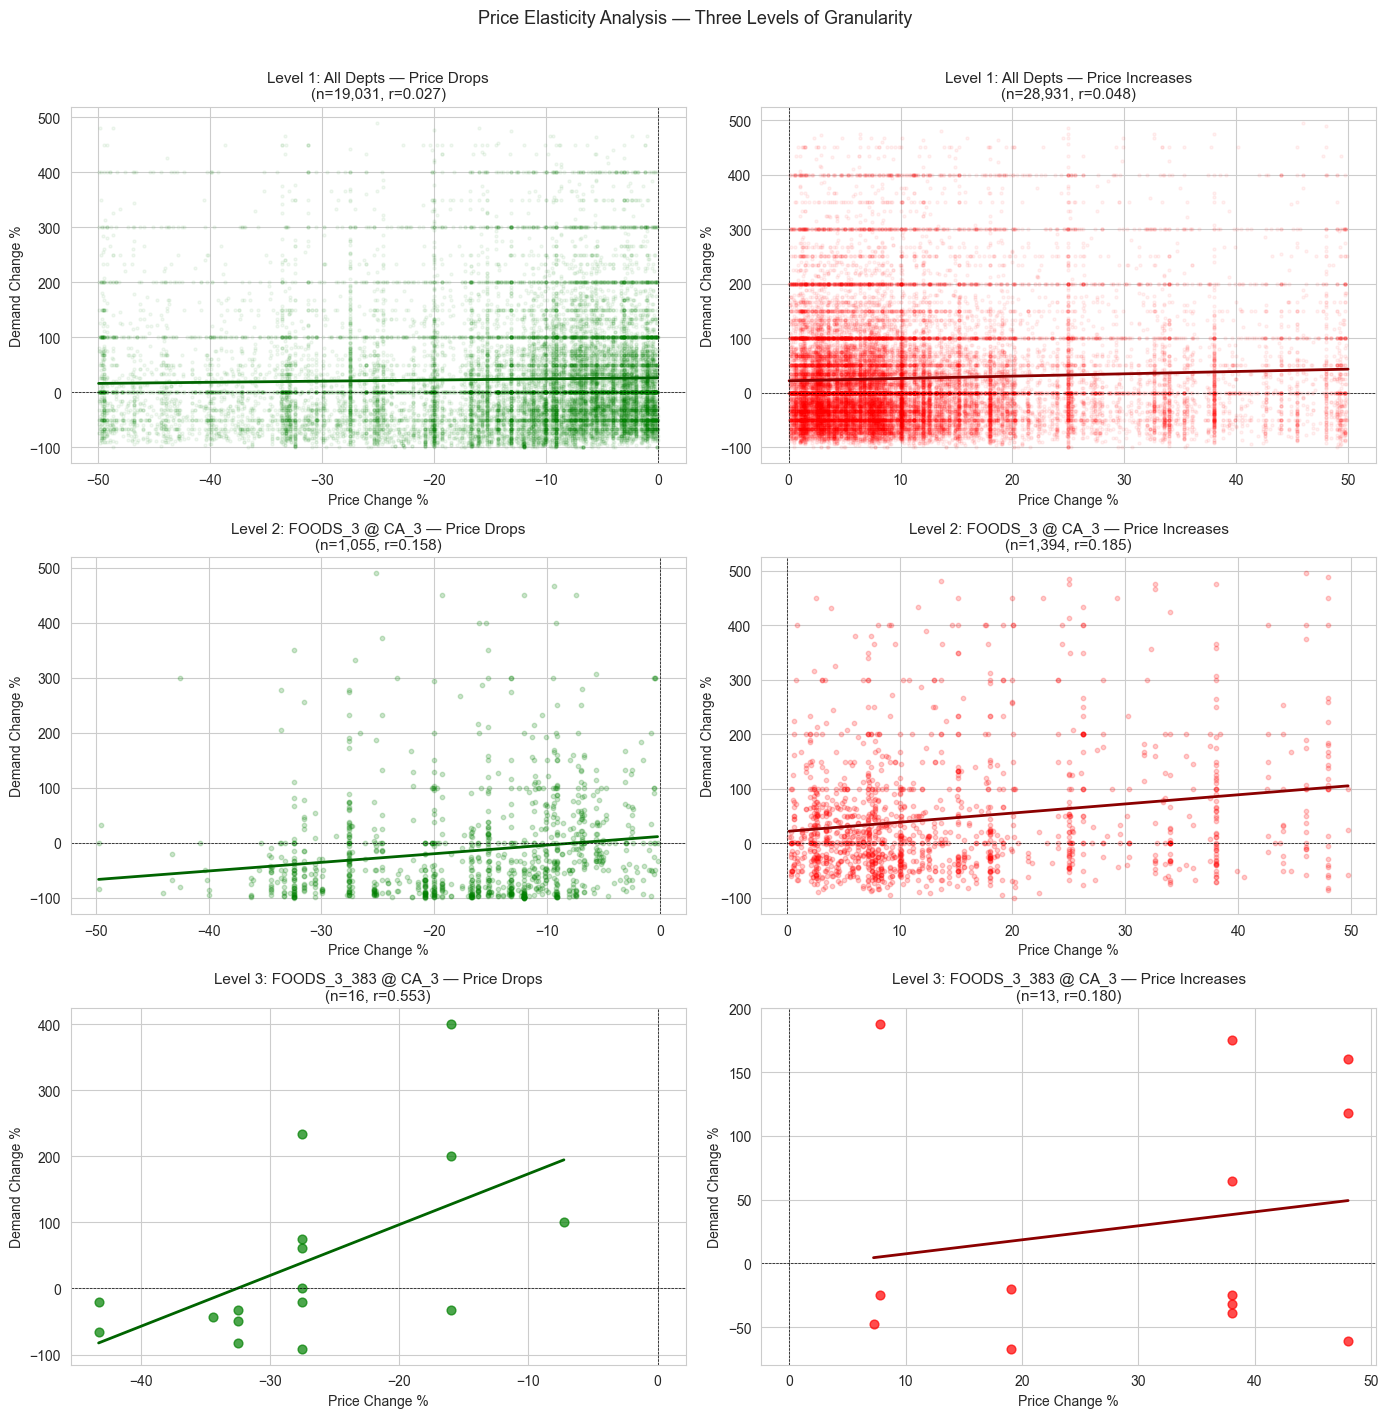

In [6]:
show('06_price_elasticity.png')

### What the three levels show

**Level 1 — All departments, all stores (r ≈ 0.003–0.13):**
Near-zero correlation. A price change on one product is averaged across thousands
of other products with no price change — the signal is diluted to near-zero.

**Level 2 — FOODS_3 @ CA_3 (r ≈ 0.16–0.19):**
Scoping to one store and department improves the signal modestly. Still weak.

**Level 3 — Single product FOODS_3_383 @ CA_3:**
- Price drops: **r = 0.553** — a 10% price drop is associated with ~77% increase
  in observed demand
- Price increases: r = 0.180 — much weaker observed response
- **Asymmetric elasticity in observed demand confirmed**

### Why the aggregate-level scatter plots show a counterintuitive positive slope

At the department level, the scatter plots show something that looks backwards:
price drops appear associated with *lower* observed demand, and price increases
with *higher* observed demand. This is not a real demand relationship — it is
**confounding driven by reverse causality**.

Walmart does not randomly discount products. They mark down products that are
**already selling poorly** — slow movers get price cuts to clear shelf space.
So in the aggregated data, price drops and low observed demand co-occur constantly,
but not because price drops *cause* low demand. Both are caused by the same
underlying thing: a product with weak baseline demand. This confounding
completely masks the true price elasticity signal at the aggregate level.

The confounding disappears at the individual product-store level because we are
now tracking how *the same product's* observed demand changes when *its own price*
changes week over week — controlling implicitly for the product's underlying
demand level. That is when the true signal emerges.

### Modeling decision
Price features must be computed at the `item_id + store_id` level only.
Department-average price features have r < 0.13 and add no signal.
We need **signed** price change features — `price_drop_pct` and `price_increase_pct`
as separate inputs — because the asymmetric observed demand response is real.
These features are completely invisible to SARIMA and Prophet, which read only
the revenue time series.

---

## 2.5 — Finding 5: Series completeness constrains individual modeling

Before modeling individual product-store demand, we need to know how many
series have sufficient observed demand history to be statistically tractable.

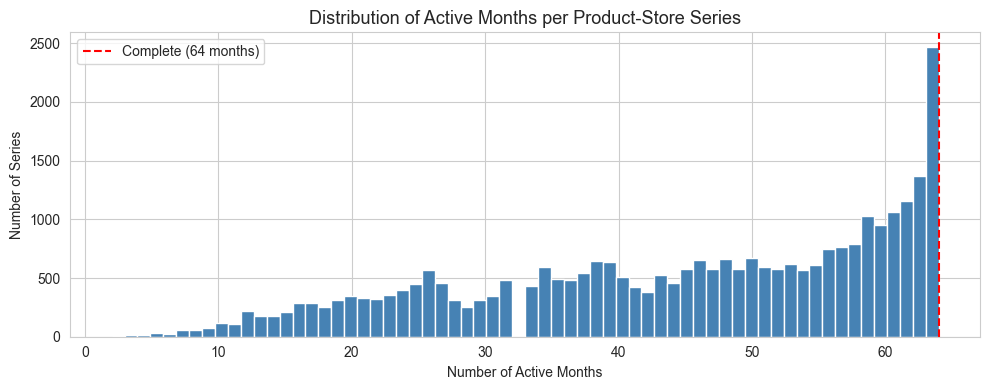

In [7]:
show('07_series_completeness.png')

### Key finding

**Only 8.1% of the 30,490 series (2,469 series) have observed demand in all 64 months.**

The other 91.9% have structural zero gaps — products introduced mid-period, discontinued,
or not stocked at specific stores. The distribution of active months is wide: some series
have only 2 active months; others have all 64. This is not a data quality issue — it
reflects real retail product lifecycle dynamics.

From a demand proxy perspective: a product absent from the shelf for 400 days shows
400 days of zero observed sales. Those zeros reflect supply absence, not demand absence.
Any model that treats them as demand signal will be misled.

### Modeling decisions
- **SARIMA** requires a continuous time index — viable only for the 2,469 complete series
- Our **representative series** is selected from these 2,469 as the one closest to the
  median total observed revenue: **FOODS_3_163 @ CA_3** (~$120/month average)
- **XGBoost** handles incomplete series row by row, but lag features must not span
  structural zero gaps — a feature pulled from a period of supply absence is not a
  demand signal

---
---

# PART 3 — STATIONARITY AND MODEL SELECTION

---

## 3.1 — What is stationarity and why does SARIMA require it?

Before fitting SARIMA, we must satisfy one fundamental mathematical requirement.

### Definition

A time series is **stationary** if its statistical properties — mean, variance —
do not change over time. A flat, noisy series with no trend is stationary.
A series with an upward trend is **not stationary** — the mean keeps rising.

### Why SARIMA requires it

SARIMA's mathematical equations assume the series fluctuates around a **stable mean**.
If the mean keeps drifting upward — as our aggregate observed demand does — the model's
core assumptions break down and parameter estimates become unreliable. We must remove
the trend before fitting.

### How we fix it: differencing

**Differencing** transforms a non-stationary series into a stationary one.

| Type | Operation | What it removes |
|---|---|---|
| **First differencing** (d=1) | Subtract each value from the previous month | Linear trend — converts demand levels to demand changes |
| **Seasonal differencing** (D=1) | Subtract the value from the same month one year ago | Annual drift — removes year-over-year demand growth |

Instead of modeling demand levels directly, we model demand *changes*.

### The ADF test — formalising the stationarity check

The **Augmented Dickey-Fuller (ADF) test** is a formal statistical test for stationarity.

- **p-value < 0.05:** stationary — the observed demand series can be modeled directly
- **p-value > 0.05:** non-stationary — trend must be removed by differencing before fitting

### Our results

| Series | Raw p-value | Verdict | Fix applied |
|---|---|---|---|
| Aggregate | 0.318 | Non-stationary | Seasonal differencing (D=1) → p=0.000 ✓ |
| Representative (FOODS_3_163) | 0.0004 | Already stationary | No differencing needed |

**Why the difference?** The aggregate observed demand series doubled over 5 years — a
strong persistent trend. The individual product-store series fluctuates around a more
stable mean with no persistent long-run drift. Different demand characteristics at
different hierarchy levels require different model specifications.

---

## 3.2 — ACF and PACF: determining the model order

Once we know how much differencing to apply, we determine the AR and MA orders
from the autocorrelation structure of the differenced series.

### Definitions

**ACF (Autocorrelation Function):** How correlated is the observed demand series
with its own past values at each lag? A significant spike at lag 3 means
"observed demand from 3 months ago carries predictive information about today."

**PACF (Partial Autocorrelation Function):** Same as ACF but removes indirect
effects of intermediate lags — isolates only the direct relationship at each distance.

### How to read them for SARIMA parameter selection

| Pattern | Parameter it identifies |
|---|---|
| PACF cuts off sharply after lag p | AR order = p |
| ACF cuts off sharply after lag q | MA order = q |
| ACF decays gradually (does not cut off) | AR process — the MA cutoff interpretation does not apply |
| Significant spikes at lag 12 | Seasonal AR (P) or seasonal MA (Q) terms needed |

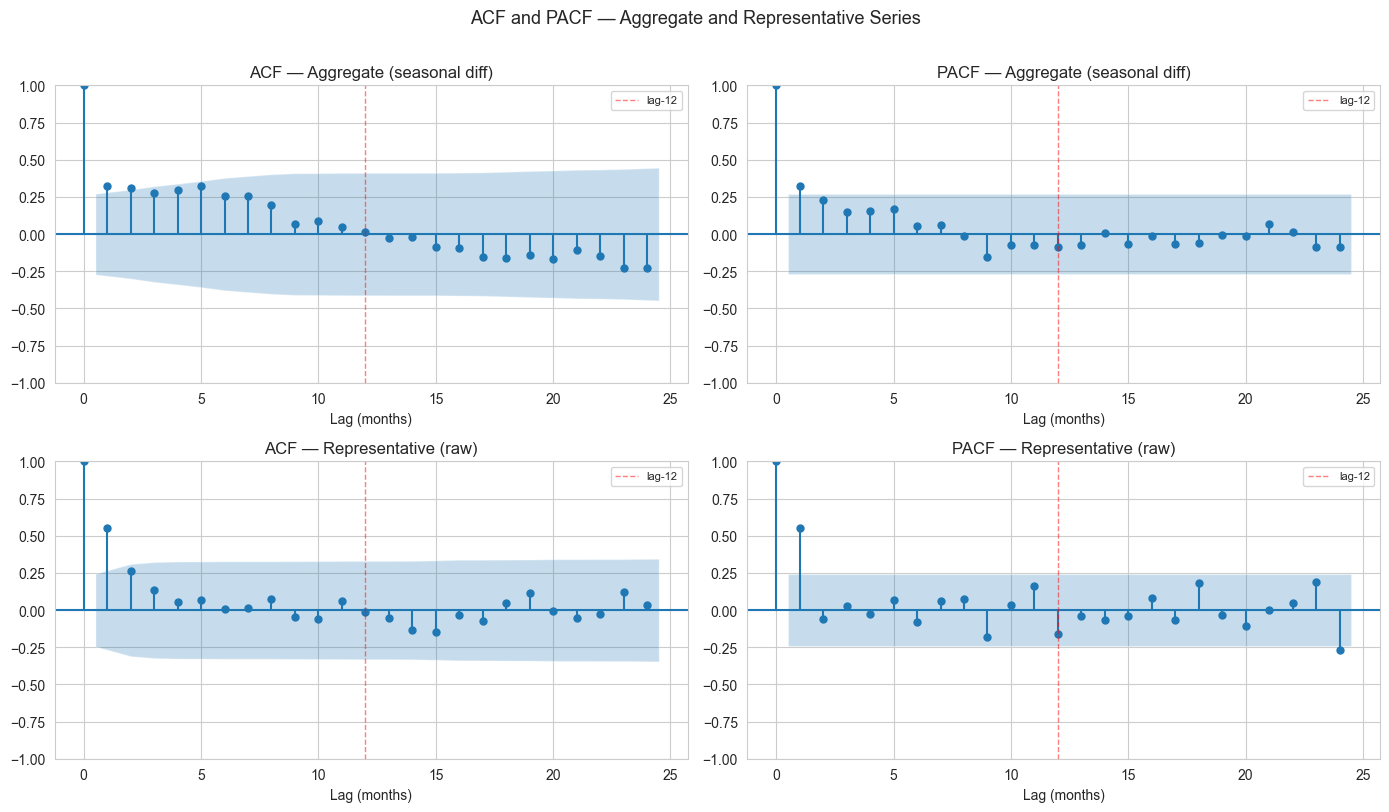

In [8]:
show('08_acf_pacf.png')

### Our readings

**Aggregate series (after seasonal differencing):**
- PACF: one significant spike at lag 1 then cutoff → **p = 1 candidate**
- ACF: significant at lags 1–5 but decays gradually (not a sharp cutoff) → **q = 0**
- Lag-12: neither ACF nor PACF significant — seasonal differencing fully removed
  the annual demand structure → **P = 0, Q = 0**

**Representative series (no differencing needed):**
- PACF: one significant spike at lag 1 only → **p = 1 candidate**
- ACF: significant at lags 1–2 then cuts off → **q = 1 candidate**
- Lag-12: neither significant → **P = 0, Q = 0**

These are *candidates* — the AIC grid search below confirms the final order
by fitting every candidate combination on training data and selecting the
configuration that best balances fit with complexity.

---

## 3.3 — AIC grid search: confirming the final order

ACF/PACF narrows the search space. **AIC grid search** confirms the final order
by measuring which configuration actually improves demand approximation accuracy
on training data while penalizing unnecessary complexity.

### What is AIC?

**AIC (Akaike Information Criterion)** balances two competing goals:

- **Goodness of fit:** how well does the model explain the training demand signal?
- **Complexity penalty:** each extra parameter is penalized

**Lower AIC = better model.** A model with more parameters must fit meaningfully
better to justify the added terms. With only 48 training months, holding out
a separate validation fold would cost too many observed demand data points —
AIC is the correct selection criterion here.

### Final SARIMA orders selected

| Series | Selected order | Seasonal order | Key decision |
|---|---|---|---|
| Aggregate | (2,0,1) | (0,1,1)[12] | AIC extended p to 2; D=1 confirmed from ADF |
| Representative | (0,0,1) | (0,1,1)[12] | AR dropped entirely — on this noisy intermittent demand series, last month's observed sales adds no direct predictive power; error correction (MA) is more useful than momentum (AR) |

---

## 3.4 — SARIMA: how it works as a demand approximation tool

### SARIMA(p,d,q)(P,D,Q)[m] — the six parameters

| Parameter | Name | What it controls |
|---|---|---|
| **p** | AR order | How many past observed demand values directly predict today. AR(2) = this month depends on the last 2 months. Captures demand momentum. |
| **d** | Differencing | How many times to subtract consecutive values to remove trend from the observed demand series. |
| **q** | MA order | How many past forecast errors correct today's estimate. MA(1) = last month's error adjusts this month's demand approximation. Makes the model self-correcting. |
| **P** | Seasonal AR | Same as p but at the seasonal lag — uses observed demand from 12 months ago. |
| **D** | Seasonal differencing | Subtracts the value from the same month one year ago to remove year-over-year demand drift. |
| **Q** | Seasonal MA | Corrects for last year's same-month approximation error. |
| **m** | Seasonal period | Length of one cycle. m=12 for monthly data with annual demand seasonality. |

### The key structural limitation: mean reversion

SARIMA's AR structure is **mean-reverting by design**. As the forecast horizon extends,
predictions are gradually pulled back toward the historical mean of the training data.
On a series with a strong upward demand trend, this means long-horizon approximations
will systematically underestimate observed demand. This is not a tuning failure —
it is an inherent property of how AR models extrapolate, and it directly limits
SARIMA's usefulness for demand approximation at longer horizons on trending series.
Prophet addresses this through explicit trend extrapolation.

### What SARIMA cannot see

SARIMA is a **univariate model**: it reads only the observed revenue time series.
It has no access to:
- Current or changing sell prices
- SNAP distribution calendar
- Promotional events
- Any external demand driver

These limitations are not fixable through parameter tuning. They define the
**univariate signal ceiling** that we characterise formally in Part 5.

---

## 3.5 — Prophet: a different approach to the same demand approximation problem

Prophet is built by Meta (Facebook, 2017). Instead of one unified equation,
it fits three interpretable components separately and combines them.

### The Prophet equation

```
y(t) = trend(t) + seasonality(t) + holidays(t) + noise
```

Each component is fitted independently then combined into a single demand approximation.

### The three components

**Trend:** A **piecewise linear curve** that automatically detects changepoints —
moments where the demand growth slope shifts. Prophet extrapolates the current slope
forward rather than reverting to the historical mean. No manual differencing required.
This is the primary reason Prophet outperforms SARIMA on the aggregate series.

**Seasonality:** Repeating demand patterns modeled using **Fourier series** — sums of
sine and cosine waves at different frequencies. For monthly data, Prophet fits annual
waves automatically. No ACF/PACF analysis needed.

**Holidays:** Accepts a dataframe of named events. Prophet fits a separate effect for
each event, incorporating the holiday-driven demand shifts we quantified in the EDA.
This is Prophet's biggest practical advantage over SARIMA.

### Key hyperparameters we tuned

| Parameter | What it controls | Aggregate winner | Individual/store winner |
|---|---|---|---|
| `changepoint_prior_scale` (cps) | Trend flexibility. Low = stiff line. High = bends aggressively to follow data. | 0.5 — flexible trend for strongly growing aggregate demand | 0.01 — stiff trend, ignores intermittent demand noise |
| `seasonality_mode` | Additive = fixed dollar seasonal swing. Multiplicative = seasonal swing scales with trend level. | multiplicative — seasonal amplitude grows with demand level | additive — stable seasonal swing appropriate for sparse, intermittent demand |
| `seasonality_prior_scale` | How strongly seasonal patterns are fitted | 1.0 | 1.0 |

### How we selected hyperparameters — no data leakage

**Cross-validation on training data only.** Prophet's built-in CV slides the training
window forward, evaluates on a 12-month horizon, and we select the lowest RMSE.
The test set is never used during parameter selection — no leakage.

### What Prophet still cannot see

Like SARIMA, Prophet is a **univariate model** with a holiday extension.
The holiday component partially addresses named calendar events, but Prophet
cannot observe sell prices, SNAP flags, or promotional signals as explicit
demand drivers. The holiday effects it fits are from the named event calendar —
not the quantitative demand response signals (e.g., +17.2% TX FOODS on SNAP days)
that the EDA identified. These gaps define the signal ceiling characterised in Part 5.

### SARIMA vs Prophet — head to head

| | SARIMA | Prophet |
|---|---|---|
| **Trend handling** | Differencing removes trend; AR mean-reverts at long horizons | Piecewise linear curve; extrapolates current slope forward |
| **Seasonality** | AR/MA terms at seasonal lags | Fourier series — automatic |
| **Holiday/event effects** | None — completely blind | Named event component |
| **External demand drivers** | None | None — still univariate |
| **Parameter selection** | ADF, ACF/PACF, AIC grid | CV grid search |
| **Strength** | Rigorous on stationary series with clear autocorrelation | Handles trend changes and named holidays naturally |
| **Shared weakness** | Cannot observe price, SNAP, or promotional demand signals | Cannot observe price, SNAP, or promotional demand signals |

---
---

# PART 4 — BASELINES AND THE AGGREGATE DEMAND SERIES

---

## 4.1 — Train/test split and evaluation framework

Before any results mean anything, we need a fair and leak-free evaluation framework.

### The split

| Period | Months | Date range |
|---|---|---|
| **Training** | 48 months | Feb 2011 → Jan 2015 |
| **Test (held out)** | 12 months | Feb 2015 → Jan 2016 |

**Strictly time-based** — no shuffling, no random sampling. Every model is trained
on identical data and evaluated on the identical test period. This is the only valid
framework for time series: a model cannot use future observed demand to estimate past demand.

### The three evaluation metrics

| Metric | Formula | What it measures |
|---|---|---|
| **RMSE** | √(mean of squared errors) | Average approximation error in dollars; penalizes large errors more heavily |
| **MAE** | Mean of absolute errors | Average dollar error per month; less sensitive to outliers than RMSE |
| **MAPE** | Mean of \|error / actual\| × 100 | Average error as % of observed demand; unit-free and comparable across hierarchy levels |

**MAPE is our primary metric** — it is directly comparable across the aggregate
series, store-level series, and individual product-store series despite their
very different revenue scales.

### Naive baselines — the floor every model must beat

**Naive (persistence):** Next month's demand ≈ this month's observed value.
The simplest possible approximation. A demand intelligence system that cannot
beat this has no decision-support value over what a planner could do manually.

**SMA(3):** 3-month simple moving average. Slightly smoother than naive.

**Noteworthy:** On the aggregate series, naive (8.96% MAPE) beats SMA(3) (10.71% MAPE).
This happens because the aggregate demand series has a strong upward trend —
the most recent observed value is already the best single-point estimate.
SMA averages in older, lower values and systematically underestimates rising demand.

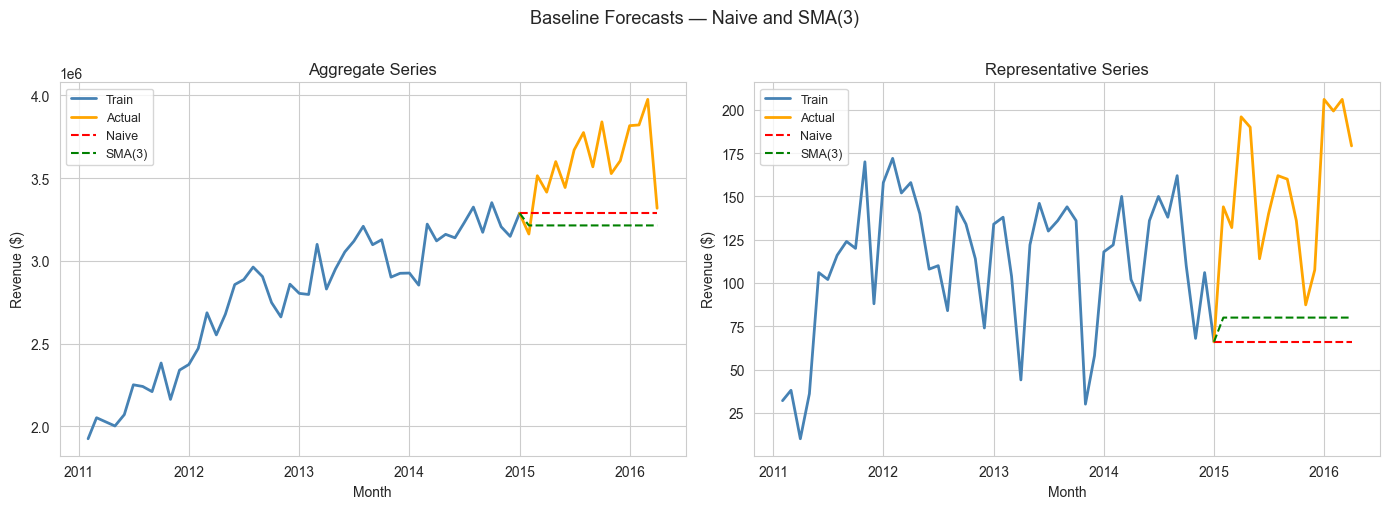

In [9]:
show('09_baseline_forecasts.png')

---

## 4.2 — SARIMA demand approximation: aggregate series

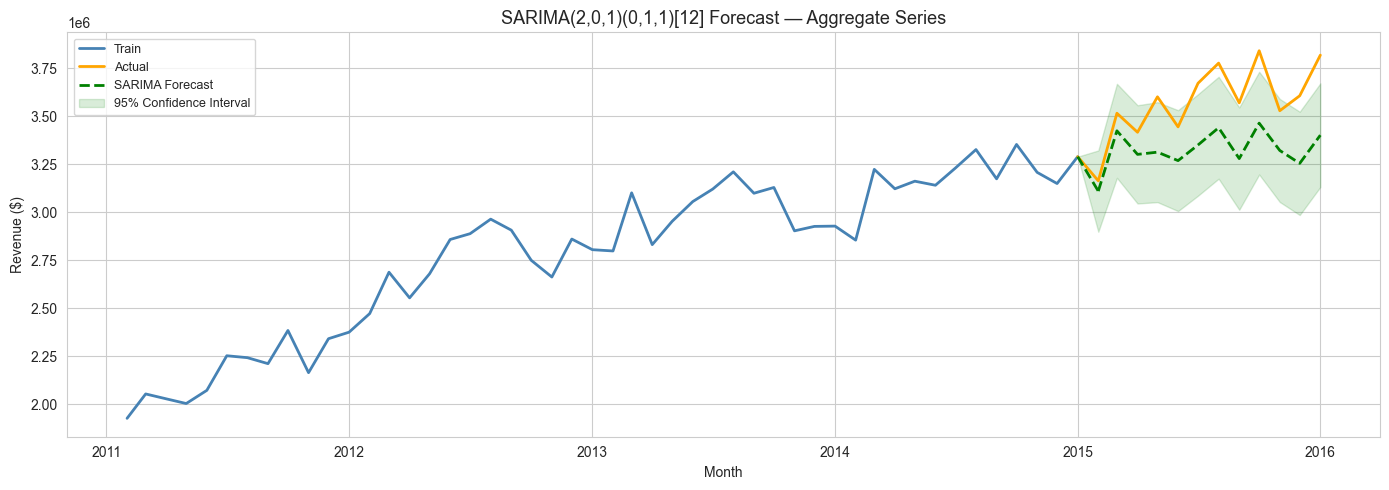

In [10]:
show('10_sarima_aggregate.png')

### Results: SARIMA(2,0,1)(0,1,1)[12]

| Metric | Value | vs Naive baseline |
|---|---|---|
| RMSE | $277,220 | −$102,831 ✓ |
| MAE | $252,147 | −$80,094 ✓ |
| MAPE | **6.91%** | −2.05 pp ✓ |

SARIMA beats the naive baseline on every metric. As a statistical demand baseline
it justifies its complexity: capturing the annual seasonal structure in observed
demand produces a meaningfully better approximation than a flat heuristic.

### What it gets right
The seasonal shape in observed demand is correctly identified. Early test months
(Feb–Apr 2015) are accurate at 1.7–3.4% error — SARIMA approximates well when
forecasting close to its training window where the learned demand patterns are
still highly relevant.

### What it gets wrong: mean reversion
Approximation errors grow progressively as the horizon extends. By month 12
(January 2016) the error reaches **10.9%**. The seasonal pattern is correct
but the model systematically underestimates the level of observed demand at
longer horizons.

This is **mean reversion** — SARIMA's AR structure gradually pulls demand
approximations back toward the historical training mean rather than continuing
the upward demand trajectory. The observed demand trend continued steeper than
SARIMA could project. This is not a tuning failure — it is an inherent structural
property of AR models, and it defines the primary limitation of SARIMA as a
demand approximation tool on growing series.

### What this error pattern tells us
The growing underestimate at longer horizons reflects genuine demand growth that
the model cannot fully extrapolate — not random noise. This directly motivates
Prophet's explicit trend extrapolation approach (Part 4.3) and XGBoost's
lag-based momentum features (Part 7).

### Confidence intervals
The 95% CI widens steadily as the horizon extends — honest and expected behavior.
By month 12, the interval spans roughly ±$500K. For a demand decision-support
system, these intervals are operationally important — planners should stock
against a communicated range, not a single point estimate.

---

## 4.3 — Prophet demand approximation: aggregate series

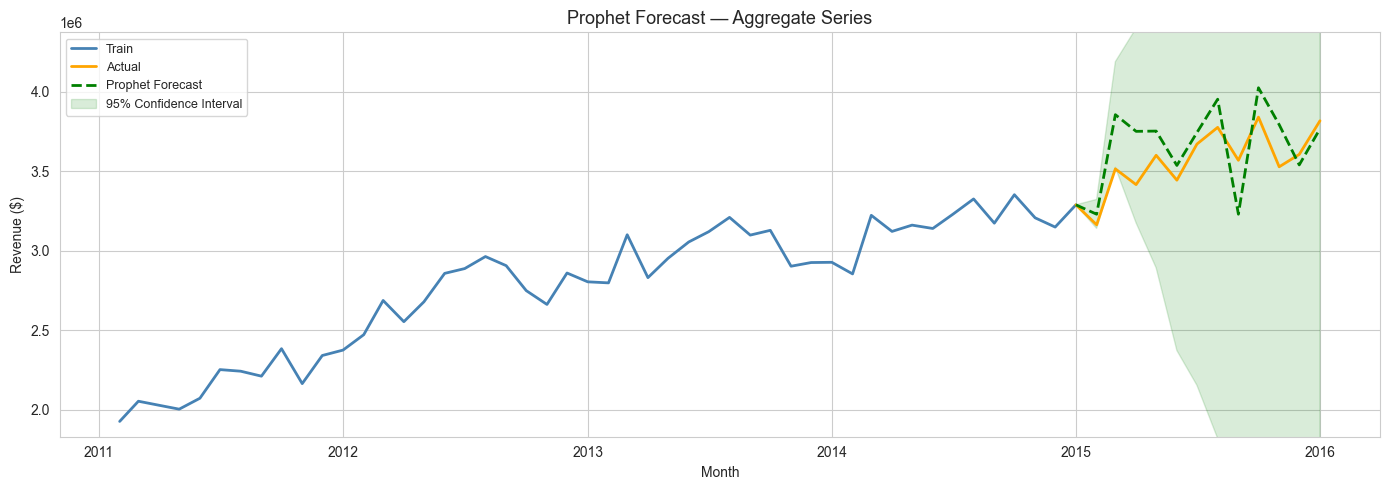

In [11]:
show('11_prophet_aggregate_forecast.png')

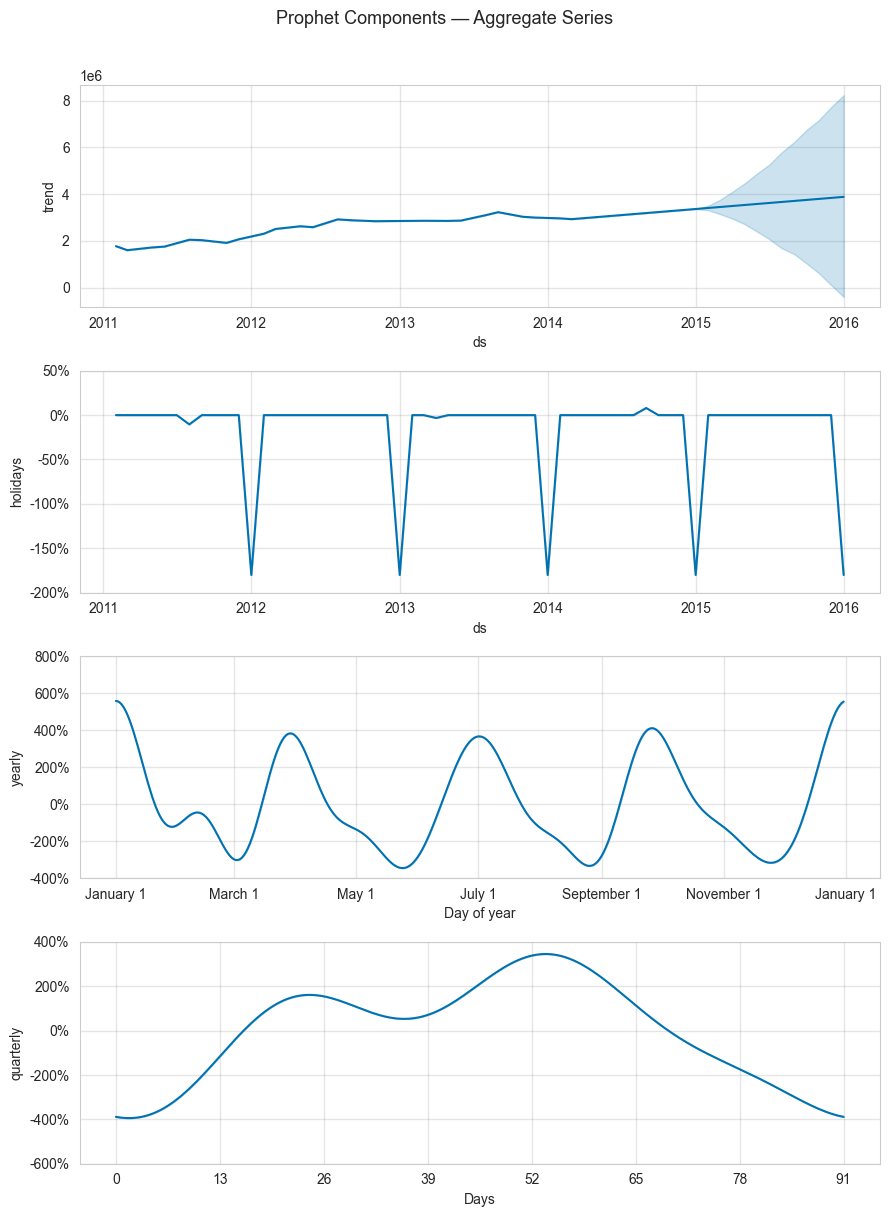

In [12]:
show('12_prophet_aggregate_components.png')

### Results: Prophet (cps=0.5, multiplicative)

| Metric | Value | vs SARIMA | vs Naive |
|---|---|---|---|
| RMSE | $209,726 | −$67,494 ✓ | −$170,325 ✓ |
| MAE | $178,567 | −$73,580 ✓ | −$153,674 ✓ |
| MAPE | **5.02%** | −1.89 pp ✓ | −3.94 pp ✓ |

**Best statistical baseline result on the aggregate demand series.**
Prophet beats every prior model on every metric.

### Why Prophet produces a better demand approximation than SARIMA here

Single reason: **trend continuation**. SARIMA's month-12 approximation error: **10.9%**.
Prophet's month-12 error: **1.3%** — on the same test month, the same observed data.
Prophet's piecewise linear trend extrapolates the observed demand trajectory forward
rather than reverting toward the training mean.

The trade-off is at short horizons: Mar–Apr 2015 show ~9.7% error vs SARIMA's 2.6–3.4%.
Prophet's flexible changepoint detection slightly overshoots the early test months —
but recovers strongly at longer horizons where SARIMA degrades significantly.

### The unexpected finding: multiplicative seasonality wins

The EDA decomposition used additive seasonality. But the CV grid search found
**multiplicative wins convincingly** — every multiplicative configuration outperformed
every additive one.

Why? As observed aggregate demand doubled from $2M to $4M per month over 5 years,
the seasonal amplitude in observed demand grew proportionally. A seasonal swing
of $150K in 2011 became ~$300K by 2016. Additive seasonality assumes a fixed dollar
amplitude — it systematically underestimates seasonal peaks in later years when the
demand baseline is higher. Multiplicative correctly scales the seasonal component
as a percentage of the trend level. This is a genuine demand structure finding,
not a parameter tuning artifact.

### Reading the component chart

- **Trend:** Clean upward slope — Prophet correctly identifies and extrapolates the observed demand growth
- **Yearly seasonality:** The repeating annual pattern in observed demand — August peaks, February troughs
- **Quarterly:** Finer within-year demand variation
- **Holiday effects:** Quantified demand shifts per named event — the direct encoding of the EDA holiday findings

### Confidence intervals

Prophet's 95% CI is wider than SARIMA's (±$1.5M by month 12 vs ±$500K) — a direct
consequence of multiplicative uncertainty: as the demand baseline grows, so does
the uncertainty band. For a decision-support system, this is the honest representation:
a planner ordering 12 months ahead should be working with a wide range, not a
narrow point estimate.

### Statistical ceiling established

Prophet at 5.02% MAPE is the best achievable with univariate statistical modeling
on this aggregate series. XGBoost (Part 7) must beat this to justify the ML layer.
The largest expected gains, however, are at the individual series and store levels —
where external demand drivers are the binding constraint, not trend extrapolation.

---
---

# PART 5 — THE INDIVIDUAL PRODUCT-STORE DEMAND SERIES

---

## 5.1 — Why individual series are harder to approximate

Everything changes when we drop from the platform aggregate to a single
product at a single store.

**The representative series: FOODS_3_163 @ CA_3**
Selected as the series closest to the median observed demand among all 2,469
complete series. Average monthly observed revenue: ~$120.

| Characteristic | Aggregate series | Individual series |
|---|---|---|
| Monthly observed demand (revenue proxy) | ~$3M | ~$120 |
| Median daily observed sales | — | 2 units |
| Demand skewness | Moderate | 11.89 (extreme) |
| Zero rate | Low (aggregated away) | 68.2% |
| Naive MAPE | 8.96% | 55.29% |

The law of large numbers smooths idiosyncratic demand noise at the aggregate level.
At the individual level, one promotion, one price change, or one SNAP distribution
event can double or halve a month's observed sales. The approximation problem is
fundamentally harder — and the baseline is dramatically higher.

---

## 5.2 — SARIMA approximation: individual series

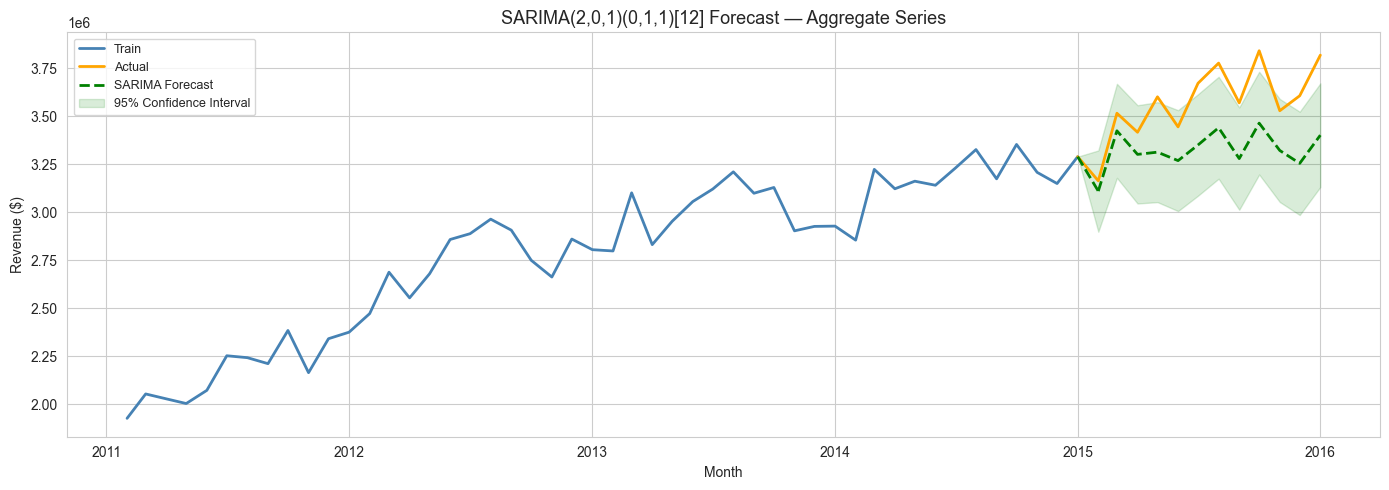

In [13]:
show('10_sarima_aggregate.png')

### Results: SARIMA(0,0,1)(0,1,1)[12]

| Metric | Value | vs SMA(3) baseline |
|---|---|---|
| RMSE | $54.41 | −$31.25 ✓ |
| MAE | $37.39 | −$39.92 ✓ |
| MAPE | **22.22%** | −23.58 pp ✓ |

SARIMA nearly halves the baseline error — a 51% relative improvement.
Capturing the annual seasonal demand pattern is real and exploitable even at
the individual series level.

### The model order change is itself informative

The representative series selected **p=0** — no AR term. On a noisy,
intermittent observed demand series, last month's actual sales value adds no
direct predictive signal for next month's demand. Month-to-month observations
are too erratic for momentum to be useful. The model relies entirely on error
correction (MA terms) rather than momentum (AR terms) — the correct behavior
when the signal-to-noise ratio in observed demand is low.

### The three months that cannot be approximated

April 2015 (54.9%), May 2015 (47.3%), January 2016 (55.6%) — errors exceeding 40%.
These errors likely reflect external demand drivers not captured by the univariate
model — a price drop, a local promotion, or SNAP distribution timing. SARIMA has
no visibility into any of these signals. This is not a model failure in the
traditional sense — it is the natural boundary of univariate demand approximation.

---

## 5.3 — Prophet approximation: individual series

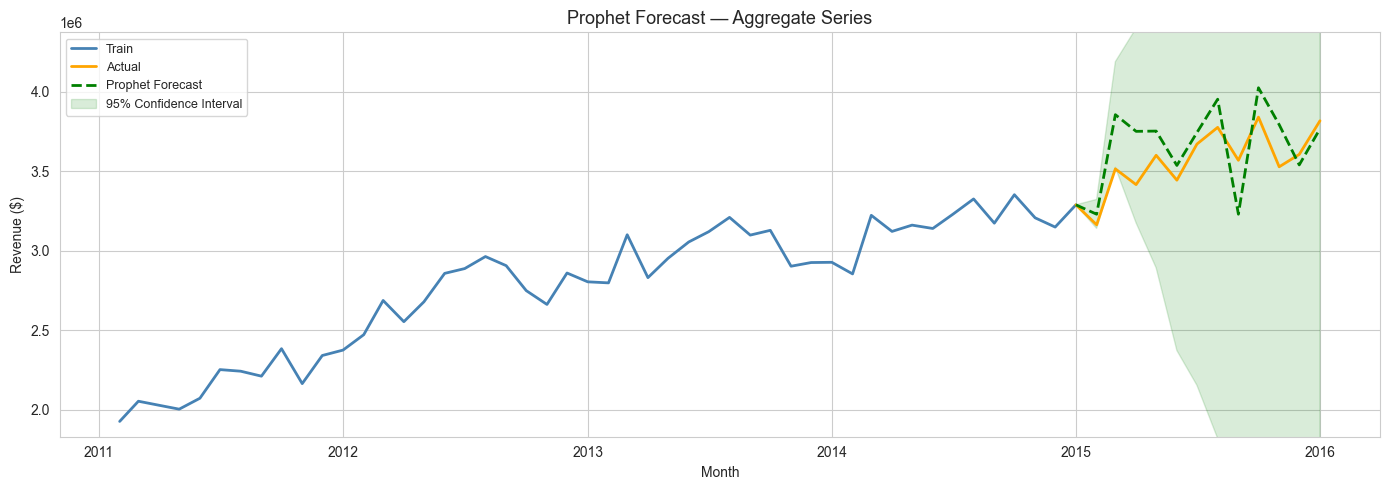

In [14]:
show('11_prophet_aggregate_forecast.png')

### Results: Prophet (cps=0.01, additive)

| Metric | Value | vs SMA(3) baseline |
|---|---|---|
| RMSE | $52.80 | −$32.86 ✓ |
| MAE | $39.68 | −$37.63 ✓ |
| MAPE | **24.25%** | −21.55 pp ✓ |

### SARIMA vs Prophet: a statistical tie

SARIMA wins on MAPE (22.22% vs 24.25%). Prophet wins on RMSE ($52.80 vs $54.41).
Neither is meaningfully better — they are approximating the same underlying observed
demand signal through different mathematical approaches and arriving at comparable accuracy.

### Why additive seasonality wins here — opposite of the aggregate

The individual series has intermittent, zero-inflated observed demand. In multiplicative
mode, Prophet scales seasonal swings as a percentage of the trend — on a series where
some months have near-zero observed sales, this produces erratic, unstable demand
approximations. Additive seasonality adds a fixed dollar swing regardless of level,
which is appropriate for sparse, lumpy demand signals.

### Why cps=0.01 wins — also opposite of the aggregate

The aggregate series had a strong, consistent upward trend worth extrapolating (cps=0.5).
The individual series fluctuates around a more stable mean — a flexible trend would
overfit to external demand shocks (price changes, promotions) that appear as jumps
in observed sales but are not structural trend shifts. A stiff trend correctly
ignores these and models the underlying demand baseline.

### The same three months fail

April 2015 (58.5%), May 2015 (49.8%), January 2016 (40.0%) — the exact same months
where SARIMA produced its largest errors, at similar magnitudes. Two completely different
model families. Same failure months. This is not a coincidence.

---

## 5.4 — The univariate signal ceiling

Two completely different model families. Calibrated independently.
Producing nearly identical large errors on the same three months.
This is the most analytically important finding of the project.

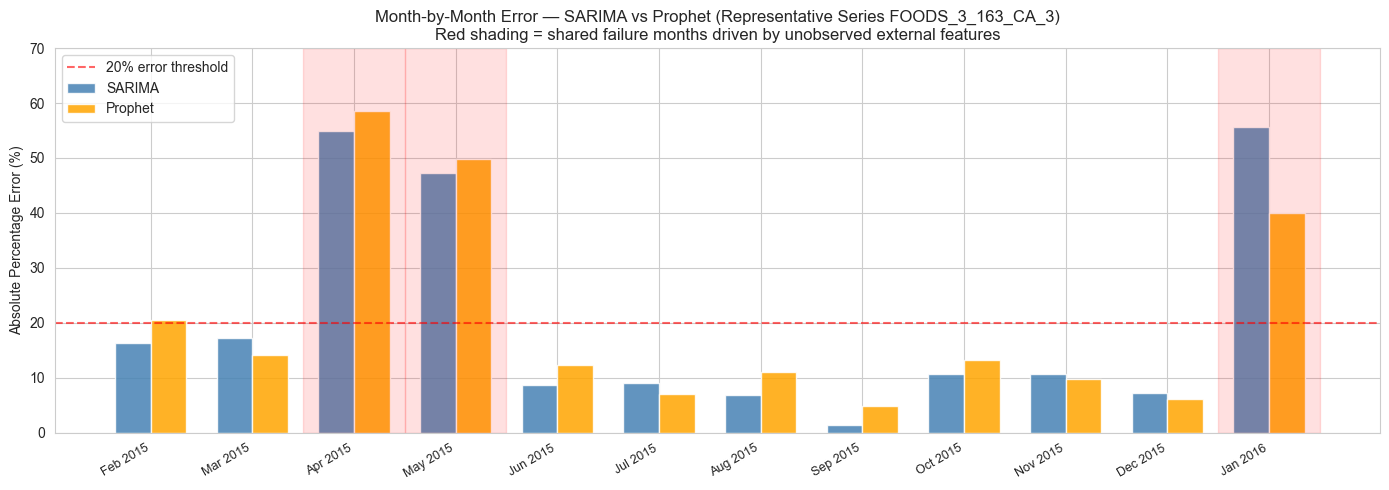

In [15]:
show('13_signal_ceiling.png')

### What is the univariate signal ceiling?

The **signal ceiling** is the maximum demand approximation accuracy achievable
using only historical observed time series data — regardless of model sophistication.
Both SARIMA and Prophet have access to exactly the same information: past observed
revenue values and calendar structure. They fail on the same months because those
months were driven by external demand factors that neither model can observe.

### What drove the shared failure months?

| Month | Most likely external demand driver | EDA evidence |
|---|---|---|
| April 2015 | Price drop event | r=0.553 for drops at product-store level — 10% price drop associated with ~77% observed demand increase |
| May 2015 | Continuation of price-driven demand | Asymmetric elasticity confirmed — stock-up behavior extends beyond the discount week |
| January 2016 | SNAP distribution timing or post-holiday restocking | CA SNAP uplift +10.3% — timing shifts in SNAP days can displace observed demand across months |

### Why no univariate model closes this gap

Both models read only the observed revenue time series. The sell price,
the SNAP calendar, and local promotional signals exist in the dataset —
but they are not in the time series that either model reads.
No amount of parameter tuning changes what data a univariate model can observe.

**The fix is not a better statistical model. It is different inputs.**

This ceiling is not a failure of the statistical baselines — it is a precise,
measurable characterisation of their information boundary. And it makes a
testable prediction: if XGBoost — with `sell_price`, `price_change_pct`,
and `snap_CA/TX/WI` as explicit features — does not substantially reduce
errors in those three specific months, the external demand driver hypothesis
is wrong. The expected improvement is not distributed randomly; it is
concentrated exactly in the months where the ceiling is hardest.

---
---

# PART 6 — STORE-LEVEL DEMAND BASELINES

---

## 6.1 — Why model stores independently?

Store-level demand approximations sit between the platform aggregate and the individual
product-store — enabling store managers to plan staffing, shelf space, and local
procurement with more granularity than a platform-wide number allows.

**Three independent Prophet models** — one per store — rather than a single shared model.
Each store has a distinct observed demand baseline, trend slope, and local demand drivers.
Forcing them into one model would require store encodings and interaction terms that add
complexity without adding signal at this stage. Cross-store demand relationships and
shared feature encoding are the job of the XGBoost layer.

**Per-store CV grid search** — aggregate parameters (cps=0.5, multiplicative) are
not assumed to transfer. The aggregate finding was calibrated on 30,490 summed series;
individual store demand has different noise profiles and structural characteristics.

### The three stores

| Store | Revenue share | Monthly demand (train avg) | CV winner |
|---|---|---|---|
| CA_3 | 17.1% | ~$560K/month | cps=0.01, multiplicative |
| CA_1 | 12.0% | ~$390K/month | cps=0.01, multiplicative |
| TX_2 | 10.9% | ~$313K/month | cps=0.05, additive |

All three stores selected stiff trends (cps ≤ 0.05) — the opposite of the aggregate
result. Individual store demand series have more noise relative to signal; a flexible
trend overfits to month-to-month demand variation rather than recovering the underlying
trajectory.

---

## 6.2 — CA_1: the best demand approximation in the project

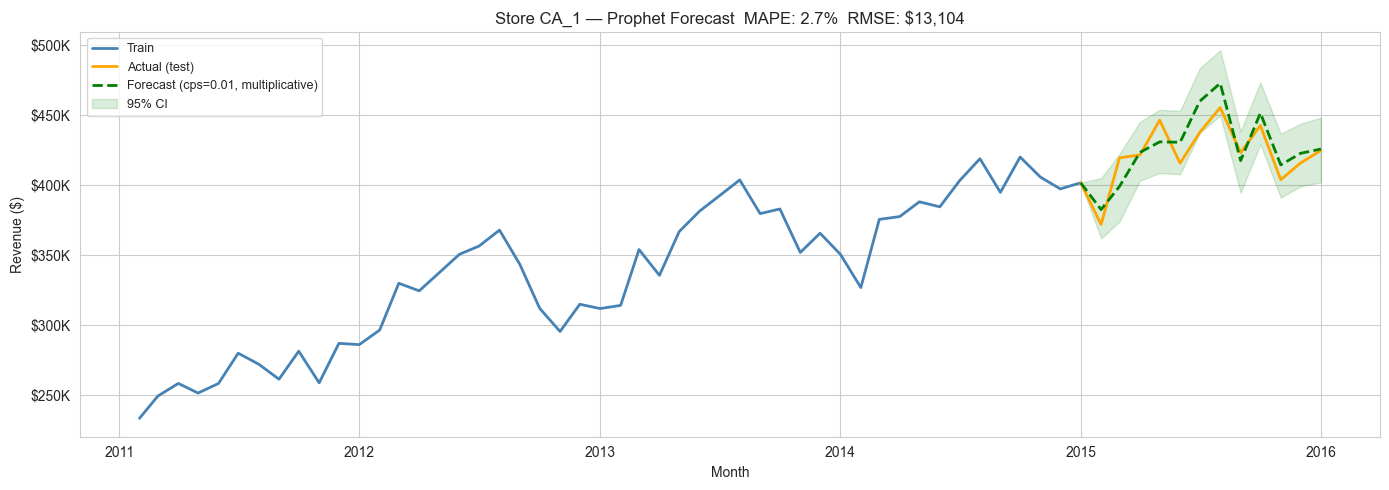

In [16]:
show('14_store_ca1_forecast.png')

### Results: CA_1 — Prophet (cps=0.01, multiplicative)

| Metric | Value |
|---|---|
| RMSE | $13,104 |
| MAE | $11,313 |
| **MAPE** | **2.66%** |

**2.66% MAPE — the best demand approximation result across any series at any
hierarchy level in this project.**

Every month lands within 5.1% of observed demand. January 2016 is just 0.2% error.
CA_1 has the smoothest, most consistent observed demand trajectory of the three stores —
exactly the conditions where a stiff univariate trend with multiplicative seasonality
approximates demand most reliably. When the observed demand signal is clean and
consistent, statistical baselines perform at their best.

---

## 6.3 — CA_3: good approximation with a consistent directional bias

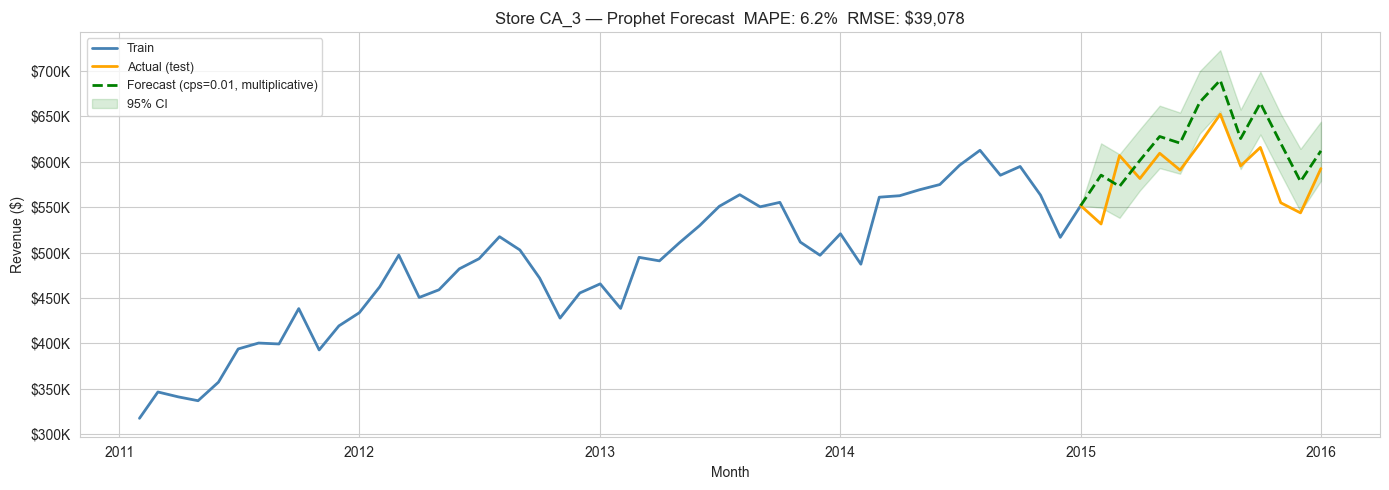

In [17]:
show('15_store_ca3_forecast.png')

### Results: CA_3 — Prophet (cps=0.01, multiplicative)

| Metric | Value |
|---|---|
| RMSE | $39,078 |
| MAE | $36,472 |
| **MAPE** | **6.23%** |

Good demand approximation overall, but with a consistent directional bias —
the model **overshoots** observed demand in almost every test month.

CA_3's actual observed demand growth decelerated slightly in the test period
relative to the training trajectory. Prophet, trained on the faster growth rate,
projects a higher demand baseline than what was actually observed. November 2015
is the largest miss at 11.8%, likely reflecting softer-than-expected pre-holiday
observed demand at this store.

The consistent direction of the bias (overshoot, not random) is operationally
informative for a decision-support system: a known directional bias can be
communicated to planners and factored into ordering decisions more reliably
than random error of the same magnitude.

---

## 6.4 — TX_2: the clearest store-level univariate ceiling

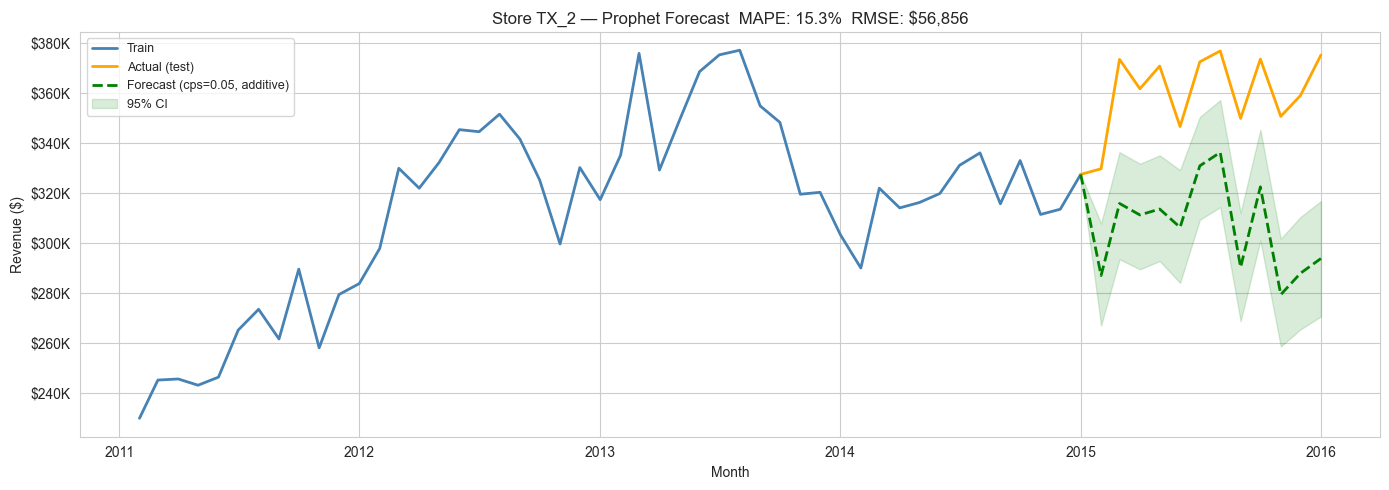

In [18]:
show('16_store_tx2_forecast.png')

### Results: TX_2 — Prophet (cps=0.05, additive)

| Metric | Value |
|---|---|
| RMSE | $56,856 |
| MAE | $55,343 |
| **MAPE** | **15.31%** |

TX_2 undershoots observed demand in every single test month. The gap widens
progressively — February 2015 error is 12.9%, January 2016 is 21.7%.
This compounding pattern is the signature of a demand growth rate underestimate:
Prophet learned a trajectory from training data that is slightly slower than
TX_2's actual observed demand delivered in the test period. The gap accumulates
month by month with no self-correction mechanism available to a univariate model.

### Why this is a structural gap, not a tuning failure

TX_2's observed demand growth accelerated from 8.2% year-over-year during training
to 11.6% in the test period. No parameter configuration available from training
data alone could have detected this acceleration — it had not yet happened.
This is a genuine demand regime shift, not a modeling error.

### Why XGBoost will matter most for TX_2

The EDA identified the most likely external driver: TX FOODS shows **+17.2%
observed demand on SNAP days**. Prophet has no access to the `snap_TX` calendar
as an explicit demand input. Price changes and local promotions are equally invisible.

These are precisely the features the XGBoost layer ingests. TX_2 is the store
where the transition from statistical baselines to machine learning will produce
the largest demand approximation improvement — the gap is large, consistent,
and directly attributable to identifiable external demand signals.

---
---

# PART 7 — MASTER COMPARISON AND CONCLUSIONS

---

## 7.1 — Master model comparison

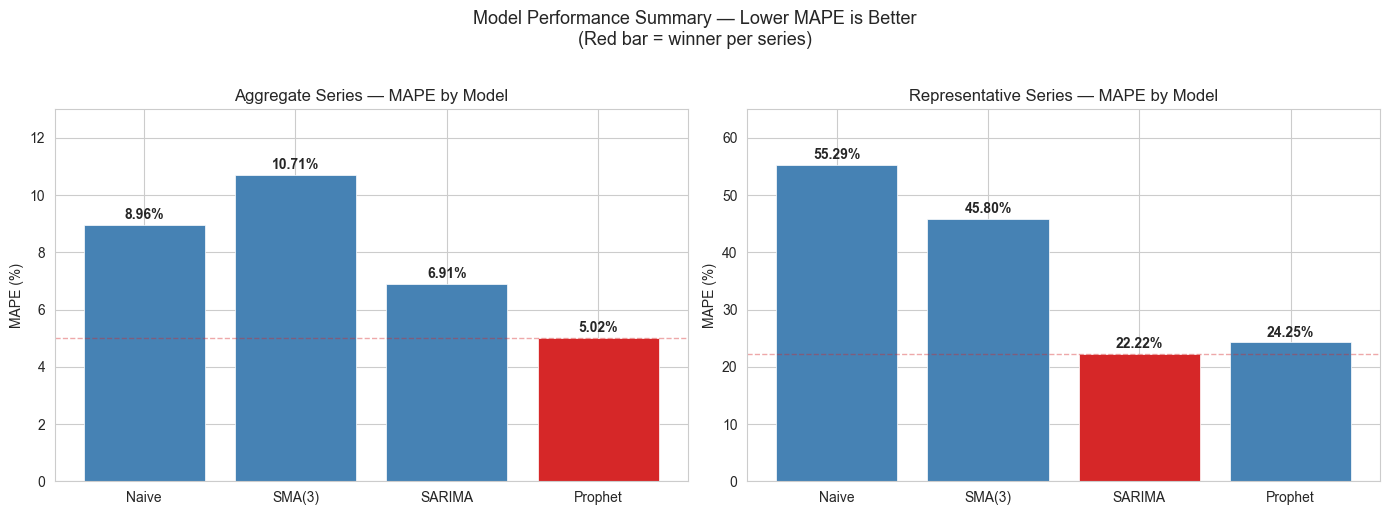

In [19]:
show('17_mape_comparison_bar.png')

All models evaluated on the same held-out 12-month test period (Feb 2015 → Jan 2016).
All metrics measure approximation of observed demand — which is itself a proxy for
true latent demand. Bold = best demand approximation per series across statistical baselines.

---

### Platform aggregate observed demand

| Model | RMSE ($) | MAE ($) | MAPE |
|---|---|---|---|
| Naive | 380,051 | 332,241 | 8.96% |
| SMA(3) | 443,310 | 396,285 | 10.71% |
| SARIMA(2,0,1)(0,1,1)[12] | 277,220 | 252,147 | 6.91% |
| **Prophet — cps=0.5, multiplicative** | **209,726** | **178,567** | **5.02%** |

---

### Individual product-store observed demand — FOODS_3_163 @ CA_3

| Model | RMSE ($) | MAE ($) | MAPE |
|---|---|---|---|
| Naive | 98.48 | 91.31 | 55.29% |
| SMA(3) | 85.66 | 77.31 | 45.80% |
| **SARIMA(0,0,1)(0,1,1)[12]** | **54.41** | **37.39** | **22.22%** |
| Prophet — cps=0.01, additive | 52.80 | 39.68 | 24.25% |

*SARIMA wins on MAPE, Prophet wins on RMSE — statistical tie.
Both hit the same signal ceiling on the same three months.*

---

### Store-level observed demand — top 3 stores by revenue

| Store | Revenue share | Model | RMSE ($) | MAE ($) | MAPE |
|---|---|---|---|---|---|
| **CA_1** | 12.0% | **Prophet — cps=0.01, multiplicative** | **13,104** | **11,313** | **2.66%** |
| CA_3 | 17.1% | Prophet — cps=0.01, multiplicative | 39,078 | 36,472 | 6.23% |
| TX_2 | 10.9% | Prophet — cps=0.05, additive | 56,856 | 55,343 | 15.31% |

*TX_2 represents the clearest store-level univariate ceiling — systematic demand
undershoot driven by unobserved SNAP and price signals. XGBoost target: < 10% MAPE.*

---

## 7.2 — Three answers to the business question

Returning to the original question with concrete results.

**Q: How well can we approximate demand at store X over the next month?**

| Hierarchy level | Best model | MAPE | Decision-support use |
|---|---|---|---|
| Platform aggregate | Prophet | 5.02% | Budget planning, category-level procurement, capacity decisions |
| Store — CA_1 | Prophet | 2.66% | Store staffing, shelf space, local procurement — reliable approximation |
| Store — CA_3 | Prophet | 6.23% | Store-level planning — reliable with known overshoot bias |
| Store — TX_2 | Prophet | 15.31% | Indicative only — external features required before this is actionable |
| Individual product-store | SARIMA/Prophet | 22.22% | Anomaly flagging and pattern identification — not precise unit-level ordering |

**Q: Are sudden demand spikes genuine demand or approximation anomalies?**

The shared failure months — April/May 2015 and January 2016 — are identified as
demand events driven by external signals not observable from time series history alone.
Both models flag them by failing to approximate them from historical patterns.
These are the highest-priority targets for anomaly detection in the next phase —
and the primary validation targets for the XGBoost feature engineering in notebook 4.

---

## 7.3 — What the XGBoost layer adds: closing the three gaps

Statistical baselines have characterised the univariate signal ceiling.
The ML layer is not about winning a benchmark — it is about closing
three specific, identified gaps in the demand approximation pipeline.

### Gap 1 — External demand drivers

SARIMA and Prophet read only past observed revenue. XGBoost ingests
external demand signals as explicit features:

| Feature | Demand signal captured | EDA evidence |
|---|---|---|
| `sell_price` | Current price level drives demand quantity | Direct demand driver at product-store level |
| `price_change_pct` (signed) | Price-driven demand response — asymmetric | r=0.553 for drops — ~77% observed demand increase per 10% price drop |
| `price_drop_pct` | Separate feature for downward price moves | Asymmetric elasticity confirmed — drops and increases have different demand effects |
| `snap_CA / snap_TX / snap_WI` | State-specific SNAP-driven demand spikes | +10.3% to +32.5% observed FOODS demand uplift by state |
| `is_event_day` | Event-driven demand shifts | SuperBowl +18.9%, Labor Day +19.6% observed uplift |

These signals are present in the dataset. They were simply not accessible
to the univariate statistical baselines.

### Gap 2 — Recent demand momentum via lag features

SARIMA's AR terms are fixed estimates from full training history and cannot
adapt to local demand acceleration. XGBoost lag features are computed from
recent actuals and reflect current demand conditions:

| Feature | What it captures |
|---|---|
| `lag_7` | Observed demand from one week ago — 7-day momentum |
| `lag_28` | Observed demand from four weeks ago — 4-week cycle |
| `rolling_mean_7` | Short-term observed demand trend |
| `rolling_mean_28` | Medium-term observed demand baseline |

This is what TX_2 needed: a model that could detect its demand growth
accelerating rather than projecting the slower training-period rate indefinitely.

**Critical constraint:** Lag features must not span structural zero gaps —
pulling a lagged value from a period when a product was unavailable conflates
supply absence with demand absence and introduces misleading signal.

### Gap 3 — Scale across the full demand hierarchy

One SARIMA per series is viable only for the 2,469 complete series (8.1%).
XGBoost trains one model across all 30,490 product-store combinations simultaneously,
using `store_id` and `dept_id` encodings to learn individual demand baselines
within a shared model. Evaluated via **walk-forward cross-validation** —
no future observed demand data is ever used to train any fold.

### Expected demand approximation targets for notebook 4

| Series | Statistical baseline | XGBoost target | Primary driver of expected gain |
|---|---|---|---|
| Aggregate | 5.02% MAPE | Marginal improvement | Prophet already handles trend well; limited upside |
| Representative (FOODS_3_163) | 22.22% MAPE | < 15% | Price and SNAP features address the exact failure months |
| TX_2 store | 15.31% MAPE | < 10% | `snap_TX` + lag features address the systematic demand undershoot |

---

## 7.4 — Limitations of this demand intelligence system

| Limitation | Impact on demand approximation |
|---|---|
| **Observed sales ≠ true demand** — no inventory or stockout records | Zero observed sales may reflect stockout (unmet demand) or genuine demand absence — we cannot distinguish. All approximations carry this caveat |
| Revenue is derived (units × price) — not directly observed | Minor gaps where price records are missing; filled with zero, slightly understating observed demand |
| Only 8.1% of series have complete 64-month histories | SARIMA viable for 2,469 of 30,490 series only; structural zeros in incomplete series conflate supply gaps with demand gaps |
| One representative series at median observed demand | 22% MAPE is a point estimate — approximation quality varies widely across the full 30,490 series depending on volume, sparsity, and exposure to SNAP and price-driven demand events |
| All statistical baselines operate on monthly data | XGBoost targets the daily level — where zero-inflation and demand intermittency make the approximation problem substantially harder |
| Training data ends April 2016 | No e-commerce era, no COVID demand disruption — patterns may not transfer to modern retail demand contexts |
| Univariate models cannot capture cross-series demand relationships | SNAP-driven demand in FOODS may simultaneously suppress HOBBIES spending — this interaction is invisible to any single-series model |

---

## 7.5 — Project summary

| What we built | An end-to-end demand intelligence pipeline using observed sales as a proxy for latent demand, across 5.25 years of real Walmart data |
|---|---|
| **Dataset** | 30,490 product-store series, 58M rows, 3 states, 10 stores |
| **Key EDA findings** | Zero-inflation (68.2%), two types of zeros (intermittent vs structural), SNAP uplift (+10–32% by state), asymmetric price elasticity in observed demand (r=0.55 at product-store level), 8.1% complete series |
| **Statistical baselines** | Naive, SMA, SARIMA, Prophet — evaluated at 3 hierarchy levels on a strict held-out test period |
| **Best aggregate result** | Prophet 5.02% MAPE — beats naive by 3.94 pp through trend extrapolation |
| **Best store result** | CA_1 Prophet 2.66% MAPE — the best demand approximation in the project |
| **Individual series ceiling** | ~22% MAPE — SARIMA and Prophet statistically tied; both hit the same ceiling on the same three months |
| **Key analytical finding** | Signal ceiling confirmed — same 3 months produce large errors across both model families. Errors are driven by unobserved external demand factors, not model misspecification |
| **System scope** | Demand approximation for decision support. Not inventory optimization. Not true demand recovery. |
| **Next step** | XGBoost with price, SNAP, and lag features — designed to close the three specific gaps that statistical baselines cannot address from time series history alone |